In [2]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#LOAD DATASET

df = pd.read_csv('citrus.csv')

print ("=== DATA HEAD ===")
print (df.head())

print ("\n=== DATA INFO ===")
print (df.info())

print ("\n=== DATA DESCRIPTION ===")
print (df.describe())

#Checking for missing values
print ("\n=== MISSING VALUES ===")
print (df.isnull().sum())  

=== DATA HEAD ===
     name  diameter  weight  red  green  blue
0  orange      2.96   86.76  172     85     2
1  orange      3.91   88.05  166     78     3
2  orange      4.42   95.17  156     81     2
3  orange      4.47   95.60  163     81     4
4  orange      4.48   95.76  161     72     9

=== DATA INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  str    
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 468.9 KB
None

=== DATA DESCRIPTION ===
           diameter        weight           red         green          blue
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean       9.975685    175.050792   

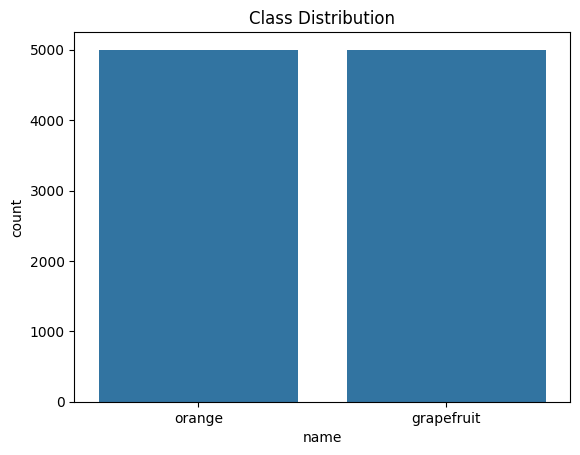

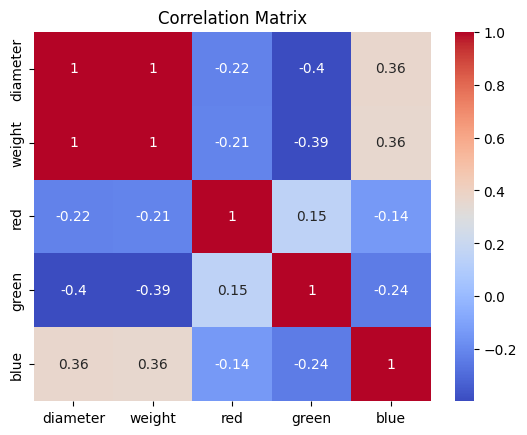

In [4]:
#VISUALIZATION

sns.countplot(x='name', data=df)
plt.title('Class Distribution')
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [5]:
#PREPROCESSING

#Encode label
le = LabelEncoder()
df['name'] = le.fit_transform(df['name'])

#Split feature & target
X = df.drop('name', axis=1)
y = df['name']

#Train test-split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
#TRAIN MODELS

#Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

#Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

#SVM
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [7]:
#PREDICTION

y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)
y_pred_svm = svm.predict(X_test)

In [8]:
#EVALUATION

print("\n=== ACCURACY ===")
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print(f" SVM Accuracy: {acc_svm:.4f}")

print("\n=== CLASSIFICATION REPORT (SVM) ===")
print(classification_report(y_test, y_pred_svm))

print("\n=== CONFUSION MATRIX (SVM) ===")
cm = confusion_matrix(y_test, y_pred_svm)
print(cm)


=== ACCURACY ===
Decision Tree Accuracy: 0.9440
Naive Bayes Accuracy: 0.9200
 SVM Accuracy: 0.9370

=== CLASSIFICATION REPORT (SVM) ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       988
           1       0.95      0.92      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000


=== CONFUSION MATRIX (SVM) ===
[[938  50]
 [ 76 936]]


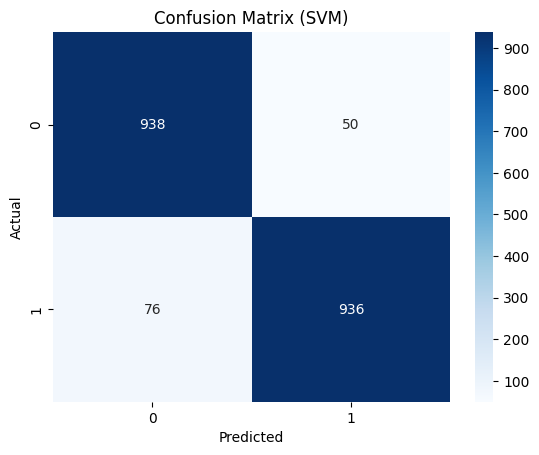

In [9]:
#VISUALIZE CONFUSION MATRIX

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


=== MODEL COMPARISON ===
           Model  Accuracy
0  Decision Tree     0.944
1    Naive Bayes     0.920
2            SVM     0.937


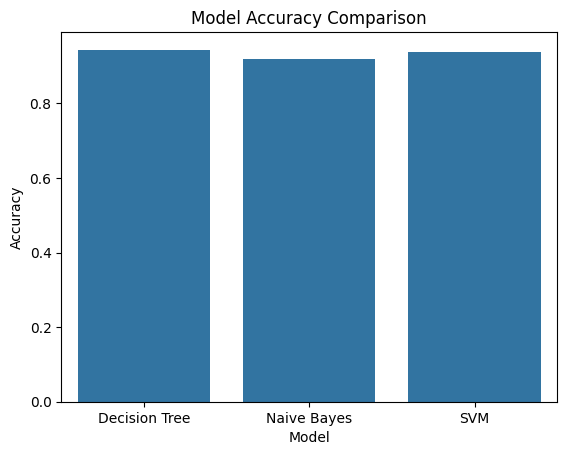

In [10]:
#MODEL COMPARISON

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'SVM'],
    'Accuracy': [acc_dt, acc_nb, acc_svm]
})

print("\n=== MODEL COMPARISON ===")
print(results)

sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Accuracy Comparison')
plt.show()